In [2]:
import qutip
from qutip import *
import numpy as np
import matplotlib.pyplot as plt

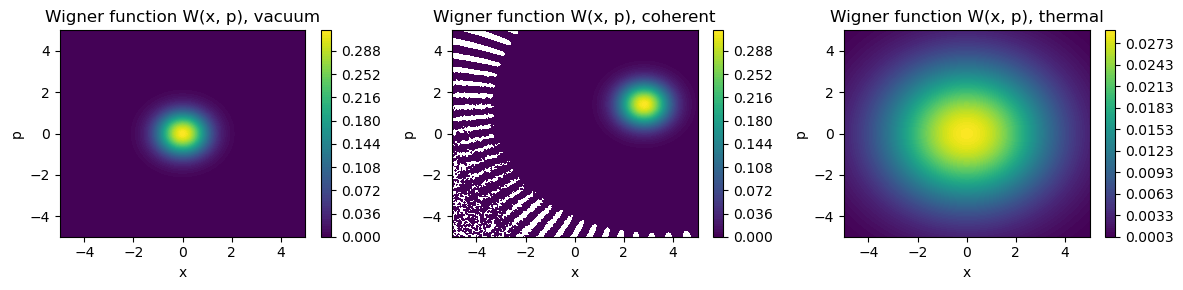

In [20]:
#Wigner function and quadrature probability distribution
N = 50  #number of fock states
n_th = 5  #thermal occupation
alpha = 2.0 + 1.0j

vac = basis(N, 0)  #vacuum state
coh = coherent(N, alpha)  #coherent state
ther = thermal_dm(N, n_th)  #thermal state

x = np.linspace(-5,5,200)
states = [
    ('vacuum', vac),
    ('coherent', coh),
    ('thermal', ther),
]

#wigner functions
fig, axes = plt.subplots(1, 3, figsize=(12,3))
for i, (title, state) in enumerate(states):
    w = wigner(state, x, x)
    image = axes[i].contourf(x, x, w, 100)
    fig.colorbar(image, ax=axes[i])
    axes[i].set_title(f'Wigner function W(x, p), {title}')
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('p')
plt.tight_layout()
plt.show()

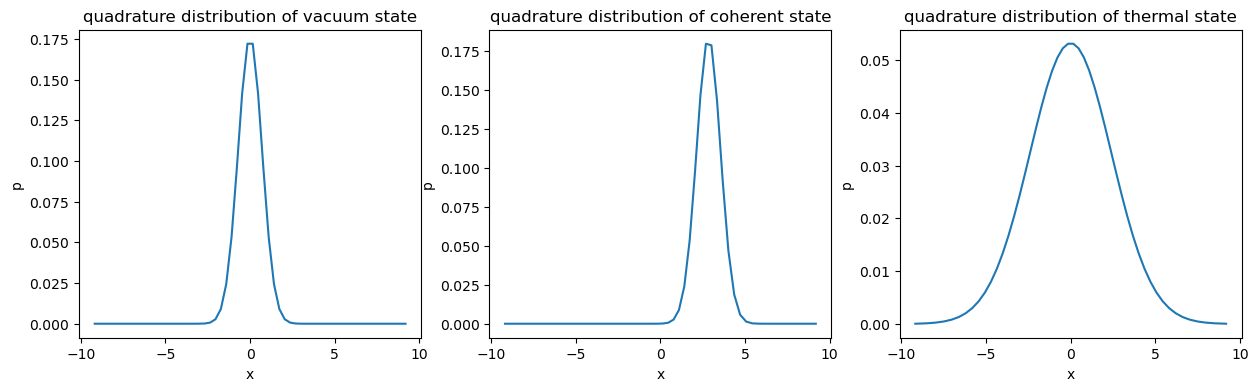

In [4]:
#quadrature probability distributions
def quadrature_distribution(psi, theta):
    N = 50
    a = destroy(N)
    a_dag = create(N)
    x_hat = (a*np.exp(-1j*theta) + a_dag*np.exp(1j*theta)) / np.sqrt(2)  #quadrature operator, phase dependent
    x_eigenvalue, x_eigenstate = x_hat.eigenstates()  #eigenvalues and eigenstates of quadrature operator
    
    p = np.array([
        np.abs(x_k.dag()*psi)**2 for x_k in x_eigenstate
    ])     #quadrature probability distribution
    x = x_eigenvalue   #eigenvalues of quadrature operator, values upon measurement
    return x, p

def quadrature_distribution_mixed(rho, theta):
    N = 50
    a = destroy(N)
    a_dag = create(N)
    x_hat = (a*np.exp(-1j*theta) + a_dag*np.exp(1j*theta)) / np.sqrt(2)  #quadrature operator, phase dependent
    x_eigenvalue, x_eigenstate = x_hat.eigenstates()  #eigenvalues and eigenstates of quadrature operator

    p = np.array([
        np.real(x_k.dag()*rho*x_k) for x_k in x_eigenstate
    ])      #quadrature probability distribution, mixed state
    x = x_eigenvalue   #eigenvalues of quadrature operator, values upon measurement
    return x, p
    
fig1, axe1 = plt.subplots(1, 3, figsize=(15,4))
x1, p1 = quadrature_distribution(vac, 0)
x2, p2 = quadrature_distribution(coh, 0)
x3, p3 = quadrature_distribution_mixed(ther, 0)

axe1[0].plot(x1, p1)
axe1[1].plot(x2, p2)
axe1[2].plot(x3, p3)
          
for i, (title, state) in enumerate(states):
    axe1[i].set_title(f'quadrature distribution of {title}')
    axe1[i].set_xlabel('x')
    axe1[i].set_ylabel('p')
plt.show()

C:\Users\LOUIS\AppData\Local\Temp\ipykernel_43320\2617145195.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_x = np.trapz(w, p, axis = 1)  #integrate over p, getting probability for x
C:\Users\LOUIS\AppData\Local\Temp\ipykernel_43320\2617145195.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_p = np.trapz(w, x, axis = 0)  #integrate over x, getting probability for p


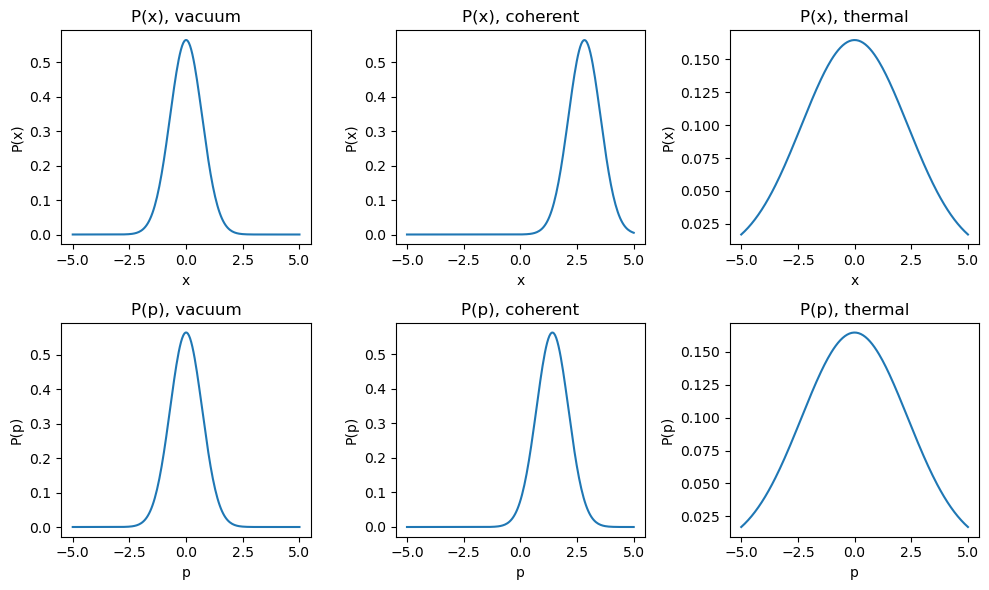

In [17]:
#integrating directly from wigner function
states = [
    ('vacuum', vac),
    ('coherent', coh),
    ('thermal', ther),
]

x = np.linspace(-5, 5, 200)
p = np.linspace(-5, 5, 200)

#wigner functions
fig, axes = plt.subplots(2, 3, figsize=(10,6))
axes = axes.flatten()
for i, (title, state) in enumerate(states):
    w = wigner(state, x, p).T
    P_x = np.trapz(w, p, axis = 1)  #integrate over p, getting probability for x
    axes[i].plot(x, P_x)
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('P(x)')
    axes[i].set_title(f'P(x), {title}')

for i, (title, state) in enumerate(states):
    w = wigner(state, x, p).T
    P_p = np.trapz(w, x, axis = 0)  #integrate over x, getting probability for p
    axes[i+3].plot(p, P_p)
    axes[i+3].set_xlabel('p')
    axes[i+3].set_ylabel('P(p)')
    axes[i+3].set_title(f'P(p), {title}')
plt.tight_layout()
plt.show()